# Agentic AI Systems 4

#### Today:
- LLM in Python
- Common LLM Parameters
- Structured output
- Simple tools and simple chatbot
- Project introduction
  

Get your Groq API key and put it into an .env
https://console.groq.com/keys

### How to load an environmental variable:

In [1]:
# load variables from .env
from dotenv import load_dotenv
import os

load_dotenv()

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")



In [2]:
from groq import Groq
import os

image_url = "C:/Users/EIVA/Downloads/Gemini_Generated_Image_h3i66ah3i66ah3i6.jpg"


client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
completion = client.chat.completions.create(
    model="qwen/qwen3.8-27b",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "What's in this image?"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_url
                    }
                }
            ]
        }
    ],
    temperature=1,
    max_completion_tokens=1024,
    top_p=1,
    stream=False,
    stop=None,
)

print(completion.choices[0].message)


BadRequestError: Error code: 400 - {'error': {'message': 'unsupported protocol: c (only http and https are allowed)', 'type': 'invalid_request_error'}}

# Grok example

In [50]:
from groq import Groq

In [40]:
client = Groq(
    api_key=GROQ_API_KEY,
)
print(client)

In [41]:
# Use this to find out what models are available to you. Try to use a small model for your homework to save time. You can also use the model "openai/gpt-oss-20b" if you want to use a large model.

models = client.models.list()

for model in models.data:
    print(model.id)

whisper-large-v3
openai/gpt-oss-120b
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-22m
openai/gpt-oss-safeguard-20b
canopylabs/orpheus-v1-english
allam-2-7b
qwen/qwen3.8-27b
whisper-large-v3-turbo
meta-llama/llama-prompt-guard-2-86m
canopylabs/orpheus-arabic-saudi


In [42]:
# get input from user
content = input("Ask a question from Groq: ")

messages=[
        {
            "role": "user",
            "content": content,
        }
    ]

model="openai/gpt-oss-20b"

chat_completion = client.chat.completions.create(
    model=model,
    messages=messages
)

print(chat_completion.choices[0].message.content)

I’m ChatGPT, an AI language model developed by OpenAI. If you’d like a nickname or a different way to address me, just let me know!


### OpenAI example

In [51]:
# load variables from .env
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")

In [27]:
from openai import AzureOpenAI

In [28]:
# Ommitted for security reasons. Please replace with your own endpoint, model name, deployment name, and API version.
endpoint = ""
model_name = ""
deployment = ""
api_version = ""

In [29]:
client = AzureOpenAI(
    api_version=api_version,
    azure_endpoint=endpoint,
    api_key=OPENAI_API_KEY,
)

In [ ]:
content = input("Ask a question from OpenAI: ")

messages=[
        {
            "role": "user",
            "content": content,
        }
    ]


response = client.chat.completions.create(
    messages=messages,
    model=deployment
)

print(response.choices[0].message.content)

## Let's use images with LLMs

In [52]:
#image_url ="../../../assets/redi_banner.png"

image_url = "C:/Users/EIVA/Downloads/Gemini_Generated_Image_h3i66ah3i66ah3i6.jpg"

In [53]:
# Open the image in jupyter:

from PIL import Image

image = Image.open(image_url)

print("Image format:", image.format)
print("Image size:", image.size)
print("Image mode:", image.mode)

Image format: JPEG
Image size: (864, 1223)
Image mode: RGB


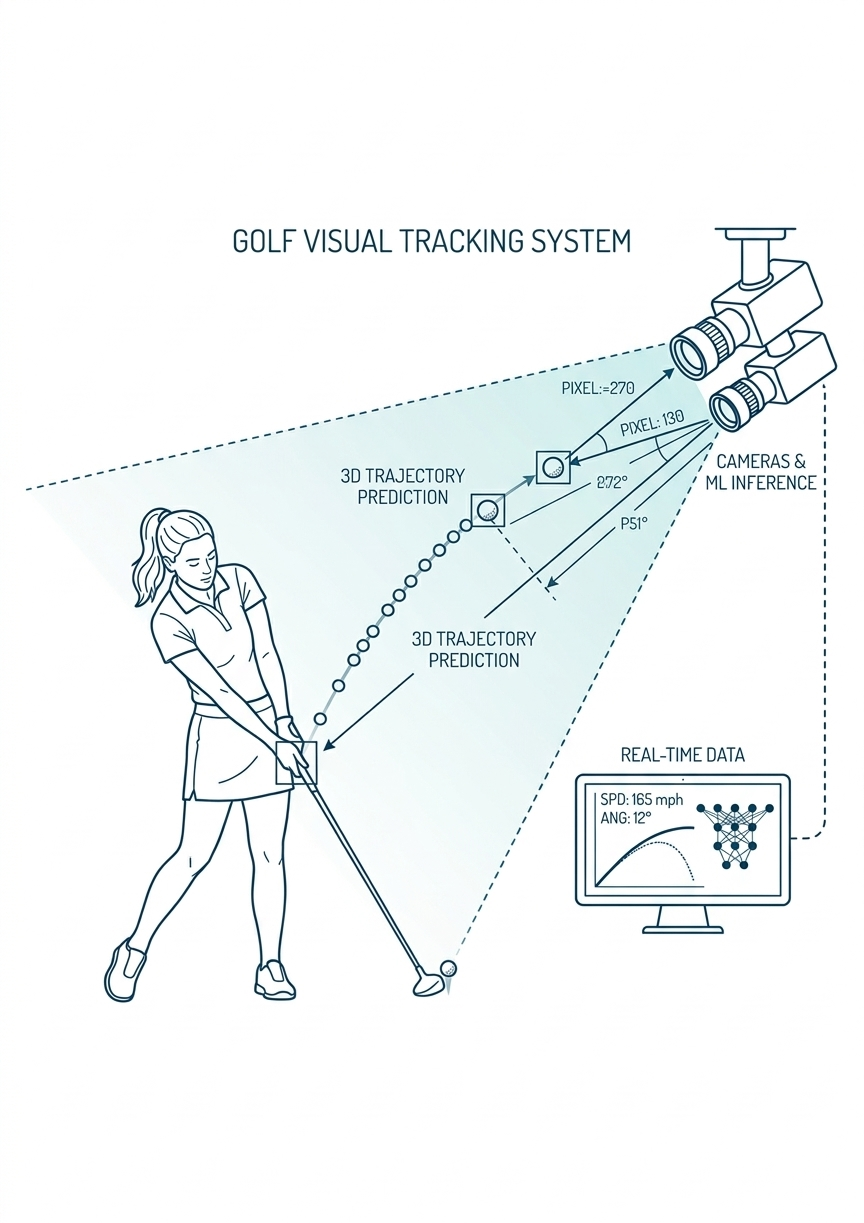

In [54]:
from IPython.display import display

display(image)

In [47]:
client = OpenAI()

print(client.base_url)

for model in client.models.list().data:
    print(model.id)

https://api.openai.com/v1/
gpt-live-1
gpt-5.6-sol
gpt-3.5-turbo-instruct-0914
gpt-6.1-sol
omni-moderation-latest
gpt-5-mini
gpt-image-1
gpt-5.5-pro-2026-04-23
gpt-5-nano
gpt-6-astra
gpt-4o-mini-tts
gpt-5.2-codex
gpt-5.1-codex-mini
o3-2025-04-16
text-embedding-3-small
gpt-4o-mini-tts-2025-03-20
babbage-002
gpt-5-search-api-2025-10-14
text-embedding-ada-002
gpt-5-chat-latest
gpt-image-2.5-flare-2026-09-08
gpt-4.1-nano
gpt-5.4-nano-2026-03-17
gpt-5.1-2025-11-13
gpt-transcribe
o4-mini-2025-04-16
gpt-3.5-turbo-0125
gpt-4o-2024-08-06
gpt-image-2.5-flare
gpt-audio-mini-2025-12-15
chat-latest
gpt-4o-mini-search-preview-2025-03-11
gpt-5.5-pro
gpt-4o-mini-2024-07-18
davinci-002
gpt-realtime-2
gpt-5-pro-2025-10-06
gpt-4o-search-preview-2025-03-11
gpt-audio
o3-mini-2025-01-31
gpt-realtime-2.1
tts-1-hd
gpt-6-luna
gpt-4o-transcribe
gpt-3.5-turbo-instruct
gpt-3.5-turbo-16k
gpt-image-2-2026-04-21
gpt-live-transcribe
o3-mini
o1-2024-12-17
gpt-5-nano-2025-08-07
gpt-5.4-pro-2026-03-05
gpt-realtime-transl

In [8]:
from groq import Groq
import os
import base64

image_path = "C:/Users/EIVA/Documents/personal_documents/trachman.png"

with open(image_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")

image_url = f"data:image/jpeg;base64,{base64_image}"

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
completion = client.chat.completions.create(
    model="qwen/qwen3.8-27b",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "What's in this image?"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_url
                    }
                }
            ]
        }
    ],
    temperature=1,
    max_completion_tokens=1024,
    top_p=1,
    stream=False,
    stop=None,
)

print(completion.choices[0].message.content)


This image is a **technical or conceptual diagram** illustrating a **computer vision system analyzing a golf swing**. It appears to be designed for educational or engineering purposes, possibly for a presentation or manual.

Here’s a breakdown of what’s shown:

---

### 1. **Golf Player (Left Side)**
- A line drawing of a female golfer in mid-swing.
- She is wearing a polo shirt and skirt, with her hair in a ponytail.
- The club is hitting a golf ball on the ground.
- A rectangular box is drawn around her lower body and the clubhead — likely indicating the **region of interest** being captured by the camera system.

---

### 2. **Dual-Camera System (Top Right)**
- Two cameras mounted side-by-side on a single bracket.
- Dotted lines extend from each camera lens toward the golfer, forming a **conical field of view**, suggesting stereo imaging (3D reconstruction).
- This setup implies the system captures synchronized images from two slightly different angles to calculate depth and 3D posi

In [15]:
# encode images to base64
import base64

def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode("utf-8")
    return encoded_string

base64_image = encode_image_to_base64(image_url)

In [16]:
print(base64_image)

...


In [ ]:
# Reuse from previous code

# Ommitted. Please replace with your own endpoint, model name, deployment name, and API version. You can find them at ai.azure.com in your foundry.
endpoint = ""
model_name = ""
deployment = ""
api_version = ""

In [ ]:

client = AzureOpenAI(
    api_version=api_version,
    azure_endpoint=endpoint,
    api_key=OPENAI_API_KEY,
)

In [17]:
message = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Describe what you see in this image."
            },
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{base64_image}"
                }
            }
        ]
    }
]

In [18]:
# get response from the model
response = client.chat.completions.create(
    messages=message,
    model=deployment
)
print(response.choices[0].message.content)

NameError: name 'deployment' is not defined

## Structured Output

### JSON

In [ ]:
content = input("Ask a question from OpenAI: ")

messages=[
        {
            "role": "system",
            "content": "You are a helpful assistant. Always respond in JSON."
        },
        {
            "role": "user",
            "content": "Give me three popular programming languages and their main uses.",
        }
    ]


response = client.chat.completions.create(
    model=deployment,
    messages=messages,
    response_format={"type": "json_object"}
)

print(response.choices[0].message.content)

### Pydantic

In [40]:
from pydantic import BaseModel
from openai import OpenAI

In [41]:
# Define our expected output structure
class ProgrammingLanguage(BaseModel):
    name: str
    use: str


class LanguageResponse(BaseModel):
    languages: list[ProgrammingLanguage]



In [43]:
messages=[
        {
            "role": "system",
            "content": "You are a helpful assistant. Always respond in JSON."
        },
        {
            "role": "user",
            "content": "Give me three popular programming languages and their main uses.",
        }
    ]


response = client.chat.completions.parse(
    model=deployment,
    messages=messages,
    response_format=LanguageResponse
)

In [44]:
# Extract the parsed response
data = response.choices[0].message.parsed

print(data)

languages=[ProgrammingLanguage(name='Python', use='Web development, data analysis, machine learning, automation, and scripting'), ProgrammingLanguage(name='JavaScript', use='Interactive websites, frontend development, backend development with Node.js, and web applications'), ProgrammingLanguage(name='Java', use='Enterprise applications, Android development, backend systems, and large-scale software')]
